### Simulated Tempering Implementation


Simulated Tempering (ST) belongs to the tempering family together with Parallel Tempering (PT).

**Plan in this notebook**

1. Run an **SMC sampler** to build a tempering ladder $\{\lambda_t\}$, $\{\log Z_t\}$, and per-level particle covariances $\{\mathrm{Cov}_t\}$.
2. Define the ST targets
   $$
   \pi_t(x)=\frac{1}{Z_t}\,\tilde\pi_{\lambda_t}(x),\qquad
   \tilde\pi_{\lambda}(x)=\pi_0(x)^{1-\lambda}\pi_1(x)^{\lambda}.
   $$
   With a uniform temperature prior, each ladder level is visited roughly equally often.
3. Transition $(t,x)\to(t',x')$ in two Metropolis–Hastings substeps:
   - **Explore:** $x'=x+\mathcal N\big(0,\frac{(2.38)^2}{d}\mathrm{Cov}_t\big)$ at fixed $t$ (Cov from SMC).
   - **Jump:** propose $t'\in\{t-1,t+1\}$ (boundary-aware proposal $q$), keep $x$ fixed.
4. Collect samples only when the chain is at the **cold** level $t=T$ ($\lambda_T=1$).

Compare later with SMC and Parallel Tempering on the same targets.


In [1]:
from pathlib import Path
import runpy

for _root in [Path.cwd(), *Path.cwd().parents]:
    _setup = _root / "setup_path.py"
    if _setup.is_file():
        runpy.run_path(str(_setup), run_name="__setup_path__")
        break

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random
from jax.scipy.stats import norm

from libs import SMC, SimulatedTempering


### State and ST sampler

Implementation: `libs/simulated_tempering.py`.

After `smc.build_intermediate_dists()`, construct with `SimulatedTempering(smc)` —
ladder (`lambda_path`, `log_z_path`, `cov_path`), `dims`, and `proposed_fn` are read from SMC.


### Demo: 1-D Gaussian mixture

Target $\pi_1$ is a bimodal mixture; base $\pi_0$ is standard normal (SMC default prior).
We first build $\{\lambda_t,\log Z_t,\mathrm{Cov}_t\}$ with SMC, then run ST on that ladder (no separate cov adaptation).


In [2]:
def mixture_logpdf(x):
    """log (0.5 N(-2,1) + 0.5 N(2,1)); supports scalar or SMC batch (n,) / (n,1)."""
    x = jnp.asarray(x)
    if x.ndim >= 1 and x.shape[-1] == 1:
        x = x[..., 0]
    return jnp.logaddexp(
        norm.logpdf(x, loc=-5.0, scale=1.0),
        norm.logpdf(x, loc=5.0, scale=1.0),
    ) - jnp.log(2.0)

Plot the pdf to show how it looks 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_12722/4159264753.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


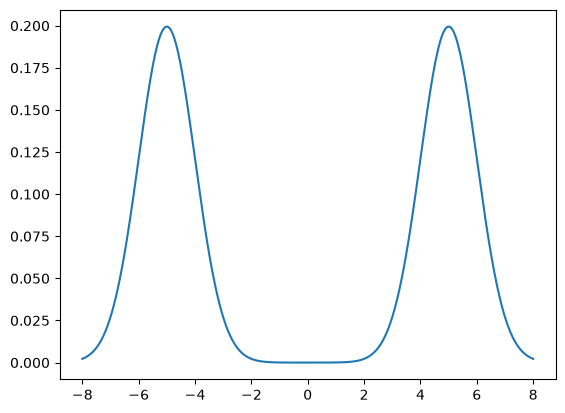

In [3]:
from matplotlib import pyplot as plt 
import numpy as np 

fig, ax = plt.subplots()
xx = np.linspace(-8, 8, 1000) 
yy = np.exp(mixture_logpdf(xx))

ax.plot(xx, yy)
fig.show()

In [4]:
# --- Stage 1: SMC ladder + Z_t + Cov_t ---
N_SMC = 10_000
smc = SMC(dims=1, target_dist_logpdf=mixture_logpdf, key=random.key(0))
smc.reset(no_samples=N_SMC)
lambda_path, log_z_path, tot_log_z, cov_path = smc.build_intermediate_dists(
    mcmc_iters=10, verbose=True
)

print(f"ladder size = {len(lambda_path)}")
print(f"lambda_path = {[round(float(l), 4) for l in lambda_path]}")
print(f"log_z_path  = {[round(float(z), 4) for z in log_z_path]}")
print(f"tot log Z   = {float(tot_log_z):.4f}")
print(f"cov_path shape = {tuple(cov_path.shape)}")


[SMC] step 0: lambda=0.0 -> 0.14501605927944183, diff_log_z=-1.2153830528259277
[SMC] step 1: lambda=0.14501605927944183 -> 0.27160051465034485, diff_log_z=-0.841221809387207
[SMC] step 2: lambda=0.27160051465034485 -> 0.38813239336013794, diff_log_z=-0.5147199630737305
[SMC] step 3: lambda=0.38813239336013794 -> 0.4999659061431885, diff_log_z=-0.214385986328125
[SMC] step 4: lambda=0.4999659061431885 -> 0.6081621050834656, diff_log_z=0.07899856567382812
[SMC] step 5: lambda=0.6081621050834656 -> 0.713352620601654, diff_log_z=0.34503650665283203
[SMC] step 6: lambda=0.713352620601654 -> 0.8226363062858582, diff_log_z=0.6545372009277344
[SMC] step 7: lambda=0.8226363062858582 -> 0.9293047785758972, diff_log_z=0.9293270111083984
[SMC] final step: lambda=0.9293047785758972 -> 1.0
ladder size = 10
lambda_path = [0.0, 0.145, 0.2716, 0.3881, 0.5, 0.6082, 0.7134, 0.8226, 0.9293, 1.0]
log_z_path  = [0.0, -1.2154, -2.0566, -2.5713, -2.7857, -2.7067, -2.3617, -1.7071, -0.7778, -0.0055]
tot log Z

In [5]:
# --- Stage 2: Simulated Tempering (ladder/Cov pulled from SMC) ---
st = SimulatedTempering(smc, seed=1, max_cold_keep=64)

cold_samples, n_steps, visit_counts = st.run(
    n_excursions=100_000,
    max_steps=2_000,
    key=random.key(1),
)

print(f"cold samples pooled: {int(cold_samples.shape[0])}")
print(
    f"excursion length mean/median: "
    f"{float(n_steps.mean()):.1f} / {float(jnp.median(n_steps)):.1f}"
)
vc = np.asarray(visit_counts)
print(f"visit counts by level: {vc.tolist()}")
print(f"visit fractions: {(vc / max(vc.sum(), 1)).round(3).tolist()}")
print(f"lambda at levels: {[round(float(l), 3) for l in st.lambda_path]}")
print("per-level proposal std (magic-scaled sqrt(cov_00)):")
for t in range(st.n_levels):
    prop = st.proposal_cov(t)
    print(f"  t={t}: std={float(jnp.sqrt(prop[0, 0])):.3f}")


cold samples pooled: 183938
excursion length mean/median: 20.4 / 5.0
visit counts by level: [226097, 206914, 202196, 201515, 201282, 199589, 199816, 200128, 200286, 200646]
visit fractions: [0.111, 0.102, 0.099, 0.099, 0.099, 0.098, 0.098, 0.098, 0.098, 0.098]
lambda at levels: [0.0, 0.145, 0.272, 0.388, 0.5, 0.608, 0.713, 0.823, 0.929, 1.0]
per-level proposal std (magic-scaled sqrt(cov_00)):
  t=0: std=2.390
  t=1: std=3.182
  t=2: std=4.164
  t=3: std=5.262
  t=4: std=6.439
  t=5: std=7.592
  t=6: std=8.817
  t=7: std=10.071
  t=8: std=11.311
  t=9: std=12.116


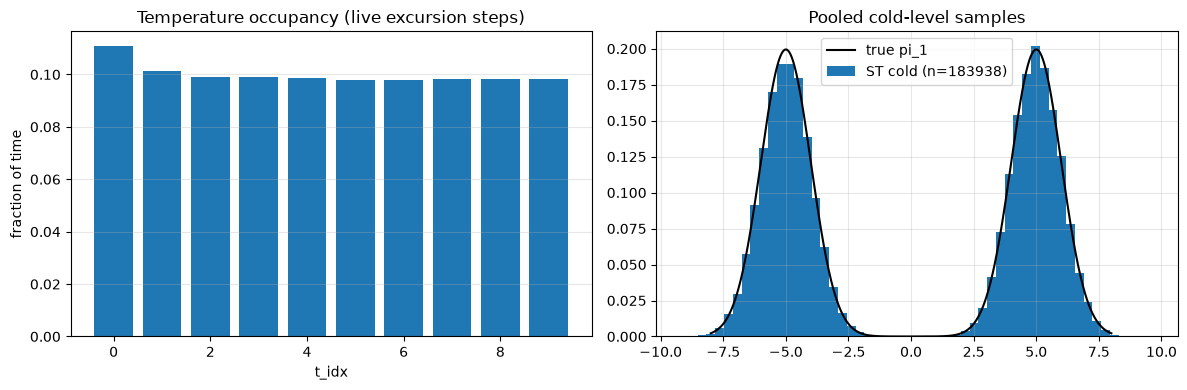

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# visit histogram
axes[0].bar(np.arange(st.n_levels), np.asarray(visit_counts) / np.asarray(visit_counts).sum())
axes[0].set_xlabel("t_idx")
axes[0].set_ylabel("fraction of time")
axes[0].set_title("Temperature occupancy (live excursion steps)")
axes[0].grid(axis="y", alpha=0.3)

# cold-level histogram vs true mixture density
xs = np.linspace(-8, 8, 1000)
ys = np.exp(mixture_logpdf(xs))
axes[1].plot(xs, ys, label="true pi_1", color="black")
if cold_samples.size:
    axes[1].hist(
        np.asarray(cold_samples).ravel(),
        bins="auto",
        density=True,
        #alpha=0.6,
        label=f"ST cold (n={cold_samples.shape[0]})",
    )
axes[1].set_title("Pooled cold-level samples")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Batched excursions via `vmap`

`run` draws `n_excursions` starting points `x0` and PRNG keys, then
`vmap`s `run_excursion(x0, key)` so independent hot→…→hot trajectories run in parallel.
Cold-level states from all excursions are pooled for the histogram.


In [7]:

# Excursions are already batched inside `st.run(...)` via vmap — no Python loop needed.
print(f"n_excursions: {int(n_steps.shape[0])}")
print(
    "excursion steps min/mean/max = "
    f"{int(n_steps.min())} / {float(n_steps.mean()):.1f} / {int(n_steps.max())}"
)
print(f"pooled cold samples: {int(cold_samples.shape[0])}")


n_excursions: 100000
excursion steps min/mean/max = 2 / 20.4 / 1011
pooled cold samples: 183938


### Notes

- Explore MH uses per-level covariance from SMC: $x'=x+\mathcal N\!\big(0,\;\frac{(2.38)^2}{d}\mathrm{Cov}_t\big)$.
- No separate `adapt_covs` pilot — `cov_path` is snapshotted during `build_intermediate_dists`.
- During `vmap(run_excursion)`, covariances are **frozen** (shared across parallel excursions).
- Jump MH still uses $\pi_{t'}(x)/\pi_t(x)$ with boundary-aware $q$-ratio.
- If occupancy stays skewed hot, lengthen excursions or refine SMC $\log Z_t$.


### Sudoku via Simulated Tempering

One sequential ST chain is enough here: we only need to **find a board with score = 0**
(a valid solution). The cold level ($\lambda=1$) is the target $\pi_1 \propto e^{-\lambda\cdot\mathrm{score}}$, which concentrates on low-score boards; success is when that score hits 0.

Explore uses the Sudoku block-swap `proposed_fn` (from `latin-square.ipynb`), not a Gaussian proposal.


In [8]:

from functools import partial
import jax
from jax import random, vmap
import numpy as np


class Scorer:
    @staticmethod
    def score_repetitive_columns(flat_board: jnp.ndarray):
        n = int(np.sqrt(len(flat_board)))
        score = 0
        for c in range(n):
            seen = jnp.zeros(n + 1, dtype=bool)
            for x in flat_board[c::n]:
                score += jnp.where(seen[x], 1, 0)
                seen = seen.at[x].set(True)
        return score

    @staticmethod
    def score_repetitive_rows(flat_board: jnp.ndarray):
        n = int(np.sqrt(len(flat_board)))
        score = 0
        for r in range(n):
            seen = jnp.zeros(n + 1, dtype=bool)
            for x in flat_board[r * n : (r + 1) * n]:
                score += jnp.where(seen[x], 1, 0)
                seen = seen.at[x].set(True)
        return score

    @staticmethod
    def score_sudoku(flat_board: jnp.ndarray):
        # Block uniqueness is enforced by construction; score rows + cols only.
        return Scorer.score_repetitive_columns(flat_board) + Scorer.score_repetitive_rows(flat_board)


def sudoku_target_logpdf(flat_board, score_fn=Scorer.score_sudoku, lam=4000.0):
    if flat_board.ndim == 1:
        return -lam * score_fn(flat_board)
    return -lam * jax.vmap(score_fn)(flat_board)


class SudokuProblem:
    """Block-complete Sudoku prior + swap proposal (from latin-square.ipynb)."""

    def __init__(self, configuration):
        self.configuration = jnp.asarray(configuration).reshape(9, 9)
        all_values = set(range(1, 10))
        self.block_unfilled_idx = []
        self.block_missing_vals = []

        log_fact = [0.0]
        for k in range(1, 10):
            log_fact.append(log_fact[-1] + float(np.log(k)))

        log_prior = 0.0
        for b in range(9):
            br, bc = divmod(b, 3)
            filled, empty_idx = set(), []
            for dr in range(3):
                for dc in range(3):
                    r, c = 3 * br + dr, 3 * bc + dc
                    v = int(self.configuration[r, c])
                    if v == 0:
                        empty_idx.append(r * 9 + c)
                    else:
                        filled.add(v)
            missing = sorted(all_values - filled)
            assert len(missing) == len(empty_idx)
            self.block_unfilled_idx.append(jnp.array(empty_idx, dtype=jnp.int32))
            self.block_missing_vals.append(jnp.array(missing, dtype=jnp.int32))
            log_prior -= log_fact[len(empty_idx)]
        self._log_prior_const = float(log_prior)

        max_k = max(len(x) for x in self.block_unfilled_idx)
        self._pad_idx = jnp.full((9, max_k), -1, dtype=jnp.int32)
        self._pad_k = jnp.zeros((9,), dtype=jnp.int32)
        for b, idx in enumerate(self.block_unfilled_idx):
            k = int(idx.shape[0])
            self._pad_k = self._pad_k.at[b].set(k)
            if k > 0:
                self._pad_idx = self._pad_idx.at[b, :k].set(idx)

    def prior_logpdf(self, flat_board):
        if flat_board.ndim == 1:
            return jnp.asarray(self._log_prior_const)
        return jnp.full((flat_board.shape[0],), self._log_prior_const)

    def init_state(self, key):
        board = self.configuration.reshape(-1).astype(jnp.int32)
        keys = random.split(key, 9)
        for b in range(9):
            idx = self.block_unfilled_idx[b]
            vals = self.block_missing_vals[b]
            k = int(idx.shape[0])
            if k == 0:
                continue
            board = board.at[idx].set(random.permutation(keys[b], vals))
        return board

    def proposed_fn(self, flat_board, key):
        pad_idx, pad_k = self._pad_idx, self._pad_k

        def propose_one(board, key):
            key_b, key_ij = random.split(key)
            eligible = pad_k >= 2
            weights = eligible.astype(jnp.float32) + 1e-8
            b = random.choice(key_b, 9, p=weights / weights.sum())
            k = pad_k[b]
            idx = pad_idx[b]

            def do_swap(board):
                noise = random.uniform(key_ij, (idx.shape[0],))
                noise = jnp.where(jnp.arange(idx.shape[0]) < k, noise, 2.0)
                order = jnp.argsort(noise)
                i0, i1 = order[0], order[1]
                p0, p1 = idx[i0], idx[i1]
                v0, v1 = board[p0], board[p1]
                board = board.at[p0].set(v1)
                board = board.at[p1].set(v0)
                return board

            return jax.lax.cond(k >= 2, do_swap, lambda board: board, board)

        if flat_board.ndim == 1:
            return propose_one(flat_board, key)
        keys = random.split(key, flat_board.shape[0])
        return jax.vmap(propose_one)(flat_board, keys)


# NYT hard puzzle (25/08/2026) from latin-square.ipynb
problem = jnp.array([
    0,0,9,0,6,0,0,0,0,
    5,0,0,4,0,0,7,3,0,
    0,0,3,0,0,2,4,0,0,
    0,0,0,8,1,0,0,0,0,
    0,1,0,0,9,0,5,0,6,
    0,0,0,0,0,6,0,0,7,
    9,0,5,0,0,0,0,0,0,
    0,2,4,6,0,0,0,1,8,
    0,0,0,0,0,0,0,7,0,
], dtype=jnp.int32)

sudoku = SudokuProblem(problem)
x0 = sudoku.init_state(random.key(0))
print("initial board:")
print(np.asarray(x0).reshape(9, 9))
print("initial score:", int(Scorer.score_sudoku(x0)))


initial board:
[[1 4 9 1 6 7 8 6 2]
 [5 7 2 4 9 3 7 3 1]
 [8 6 3 8 5 2 4 5 9]
 [4 3 9 8 1 4 4 8 3]
 [6 1 5 7 9 2 5 9 6]
 [7 8 2 3 5 6 2 1 7]
 [9 7 5 1 9 7 2 6 9]
 [1 2 4 6 3 5 5 1 8]
 [6 3 8 2 4 8 4 7 3]]
initial score: 45


In [9]:

# SMC ladder + Z_t for Sudoku (prior = block completions, target = -lam * score)
N_SMC = 2_000
key_smc = random.key(42)
k_init, k_smc = random.split(key_smc)
init_keys = random.split(k_init, N_SMC)
sudoku_particles = vmap(sudoku.init_state)(init_keys)

smc_sudoku = SMC(
    dims=81,
    target_dist_logpdf=partial(sudoku_target_logpdf, score_fn=Scorer.score_sudoku, lam=4000.0),
    prior_dist_logpdf=sudoku.prior_logpdf,
    proposed_fn=sudoku.proposed_fn,
    key=k_smc,
)
smc_sudoku.reset(samples=sudoku_particles)
lambda_path_s, log_z_path_s, tot_log_z_s, _cov_s = smc_sudoku.build_intermediate_dists(
    mcmc_iters=20, verbose=True
)
print(f"ladder size={len(lambda_path_s)}, tot log Z={float(tot_log_z_s):.4f}")
print("lambdas:", [round(float(l), 4) for l in lambda_path_s])


[SMC] step 0: lambda=0.0 -> 3.243982791900635e-05, diff_log_z=-5.70870304107666
[SMC] step 1: lambda=3.243982791900635e-05 -> 6.446697807405144e-05, diff_log_z=-5.348288536071777
[SMC] step 2: lambda=6.446697807405144e-05 -> 9.726417192723602e-05, diff_log_z=-5.186084747314453
[SMC] step 3: lambda=9.726417192723602e-05 -> 0.00012942147441208363, diff_log_z=-4.7774810791015625
[SMC] step 4: lambda=0.00012942147441208363 -> 0.00016139523359015584, diff_log_z=-4.467950344085693
[SMC] step 5: lambda=0.00016139523359015584 -> 0.00019378328579477966, diff_log_z=-4.229084014892578
[SMC] step 6: lambda=0.00019378328579477966 -> 0.00022622334654442966, diff_log_z=-3.924604892730713
[SMC] step 7: lambda=0.00022622334654442966 -> 0.0002601773012429476, diff_log_z=-3.8135337829589844
[SMC] step 8: lambda=0.0002601773012429476 -> 0.0002928684698417783, diff_log_z=-3.393383026123047
[SMC] step 9: lambda=0.0002928684698417783 -> 0.0003276673669461161, diff_log_z=-3.2938919067382812
[SMC] step 10: lam

In [ ]:
# One ST chain with Sudoku proposal — stop when score == 0
# proposed_fn / dims / ladder come from smc_sudoku
st_sudoku = SimulatedTempering(smc_sudoku, seed=7)

x_start = sudoku.init_state(random.key(1))
print("start board score:", int(Scorer.score_sudoku(x_start)))
print(np.asarray(x_start).reshape(9, 9))

x_sol, history, found = st_sudoku.run_chain(
    x0=x_start,
    n_iters=5_000,
    key=random.key(2),
    score_fn=Scorer.score_sudoku,
    print_every=500,
    start_at_hot=False,
)

print("\nfound score=0:", found)
if x_sol is not None:
    print("board:")
    print(np.asarray(x_sol).reshape(9, 9))
    print("score:", int(Scorer.score_sudoku(x_sol)))


start board score: 48
[[2 4 9 7 6 5 2 5 9]
 [5 7 6 4 1 3 7 3 6]
 [1 8 3 8 9 2 4 1 8]
 [2 3 5 8 1 4 1 9 8]
 [8 1 7 7 9 5 5 2 6]
 [9 6 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 4 1 8]
 [3 1 6 8 7 1 2 7 9]]
[chain] new best score=46 at step 1 (t=25)
[[2 4 9 7 6 5 2 5 9]
 [5 7 6 4 1 3 7 3 8]
 [1 8 3 8 9 2 4 1 6]
 [2 3 5 8 1 4 1 9 8]
 [8 1 7 7 9 5 5 2 6]
 [9 6 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 4 1 8]
 [3 1 6 8 7 1 2 7 9]]
[chain] new best score=45 at step 11 (t=21)
[[2 4 9 7 6 5 2 5 9]
 [5 7 6 4 1 3 7 3 8]
 [1 8 3 8 9 2 4 1 6]
 [2 3 5 8 1 4 1 9 8]
 [7 1 8 7 9 5 5 2 6]
 [9 6 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 2 1 8]
 [3 1 6 8 7 1 4 7 9]]
[chain] new best score=43 at step 15 (t=18)
[[2 4 9 7 6 5 2 1 9]
 [5 7 6 4 1 3 7 3 8]
 [1 8 3 8 9 2 4 5 6]
 [6 3 5 8 1 4 1 9 8]
 [7 1 8 7 9 5 5 2 6]
 [9 2 4 2 3 6 4 3 7]
 [9 7 5 5 4 2 3 6 5]
 [8 2 4 6 9 3 2 1 8]
 [3 1 6 8 7 1 4 7 9]]
[chain] new best score=41 at step 18 (t=15)
[[7 4 9 7 6 5 2 1 9]
 [5 2 6 4 1 3 7 3 8]
 

In [ ]:
print("done")